In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [3]:
# Project Root
PROJECT_ROOT = Path("..")

# Dataset Path
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"

# Read Dataset
df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
print("DATASET SHAPE")

print(df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

DATASET SHAPE
(10000, 14)

Rows : 10000
Columns : 14


In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [7]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [12]:
df.nunique().sort_values()

Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
Type                           3
Process temperature [K]       82
Air temperature [K]           93
Tool wear [min]              246
Torque [Nm]                  577
Rotational speed [rpm]       941
UDI                        10000
Product ID                 10000
dtype: int64

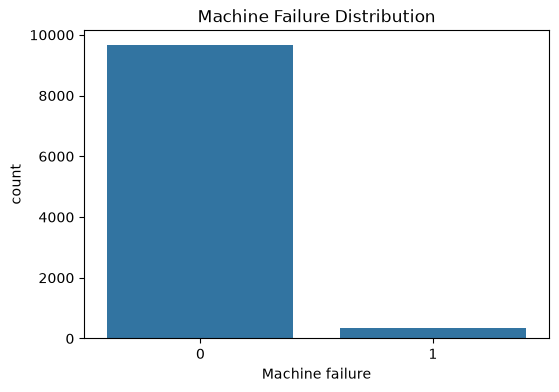

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")

plt.show()

print(df["Machine failure"].value_counts())

In [14]:
failure_percent = (
    df["Machine failure"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

failure_percent

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

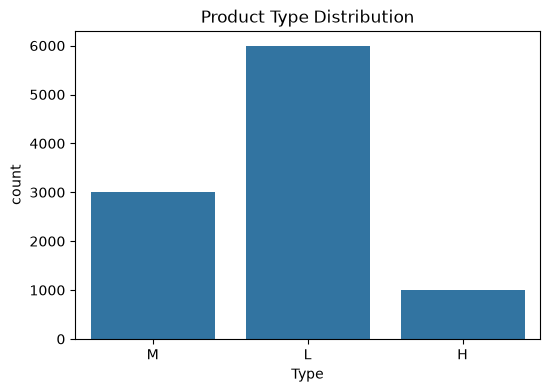

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Type")

plt.title("Product Type Distribution")

plt.show()

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

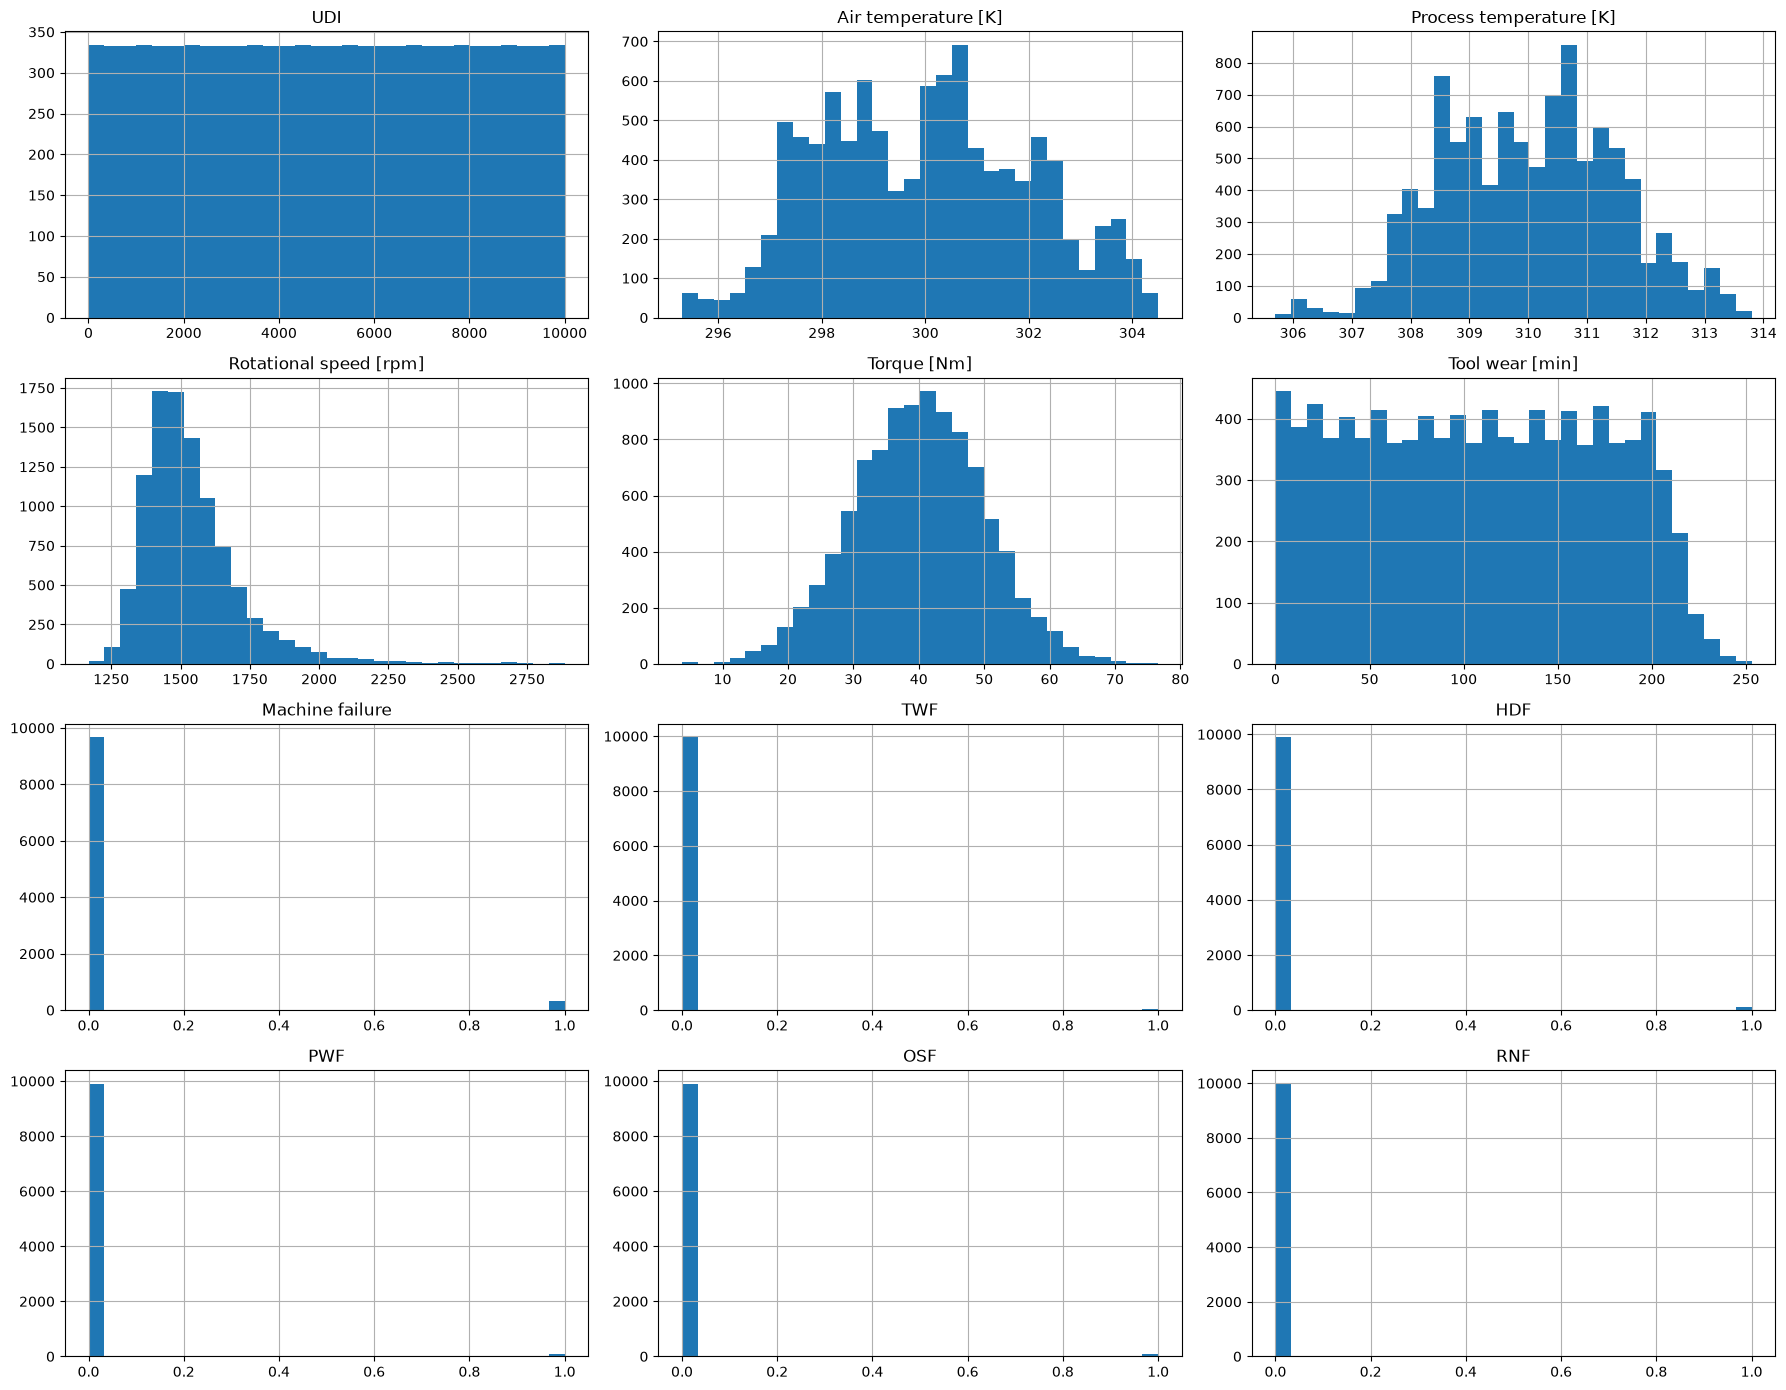

In [17]:
df[numeric_columns].hist(
    figsize=(18,14),
    bins=30
)

plt.tight_layout()

plt.show()

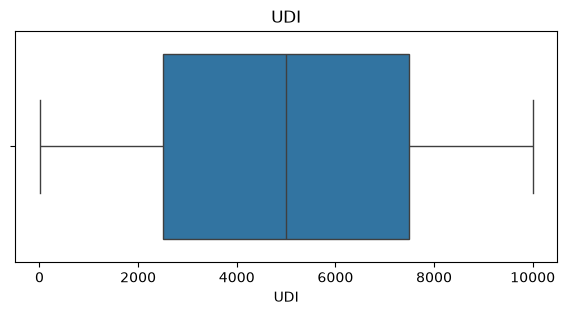

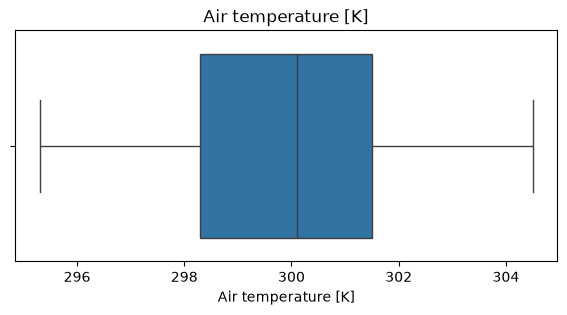

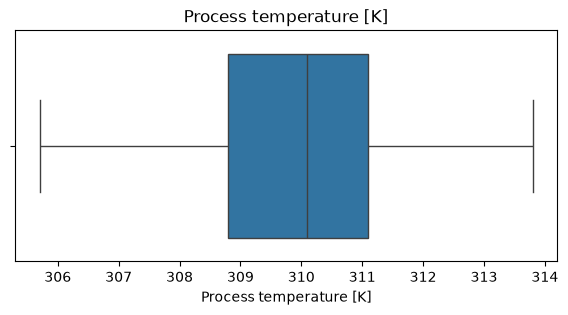

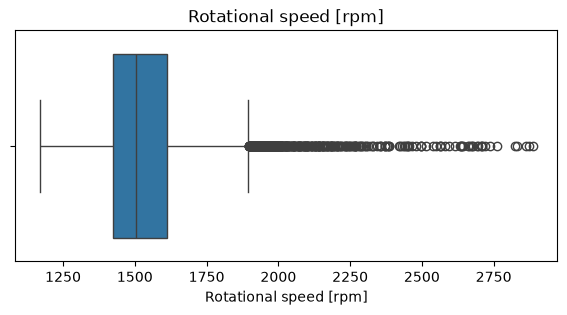

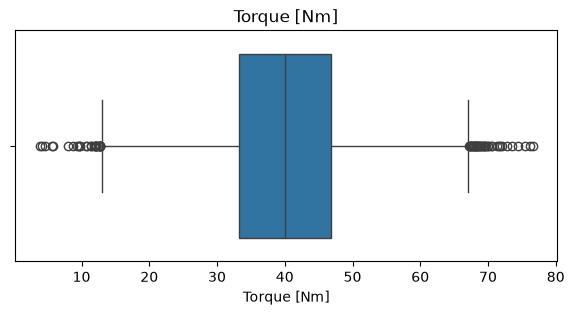

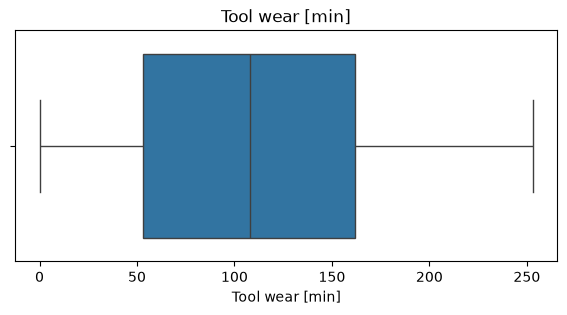

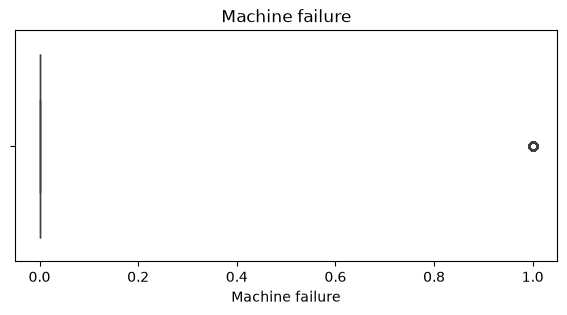

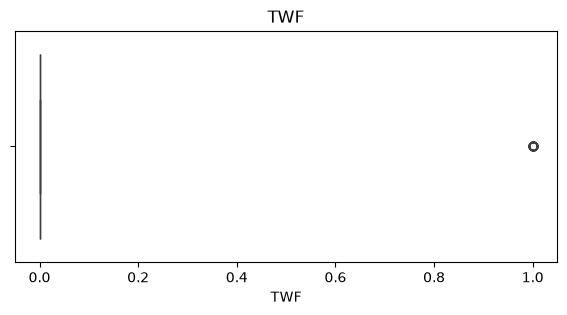

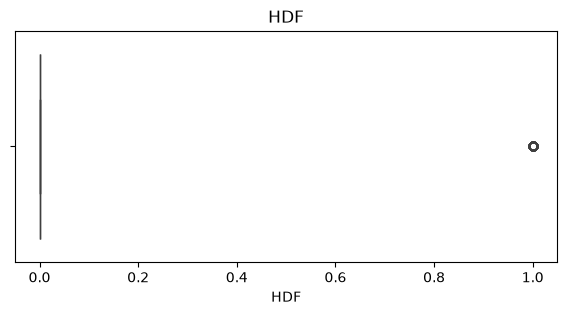

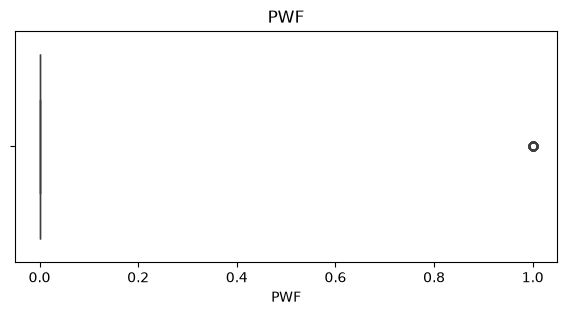

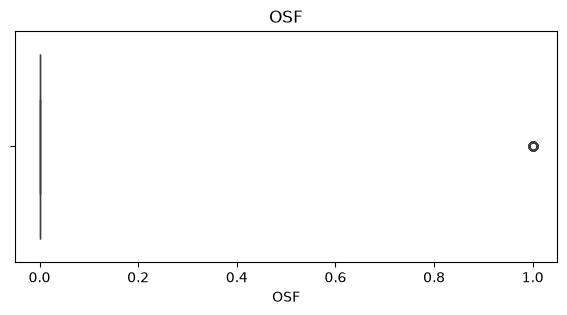

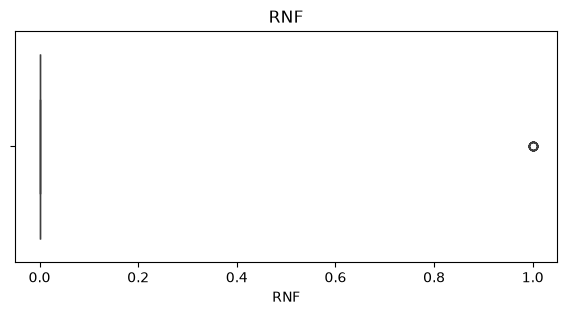

In [18]:
for col in numeric_columns:
    
    plt.figure(figsize=(7,3))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)
    
    plt.show()

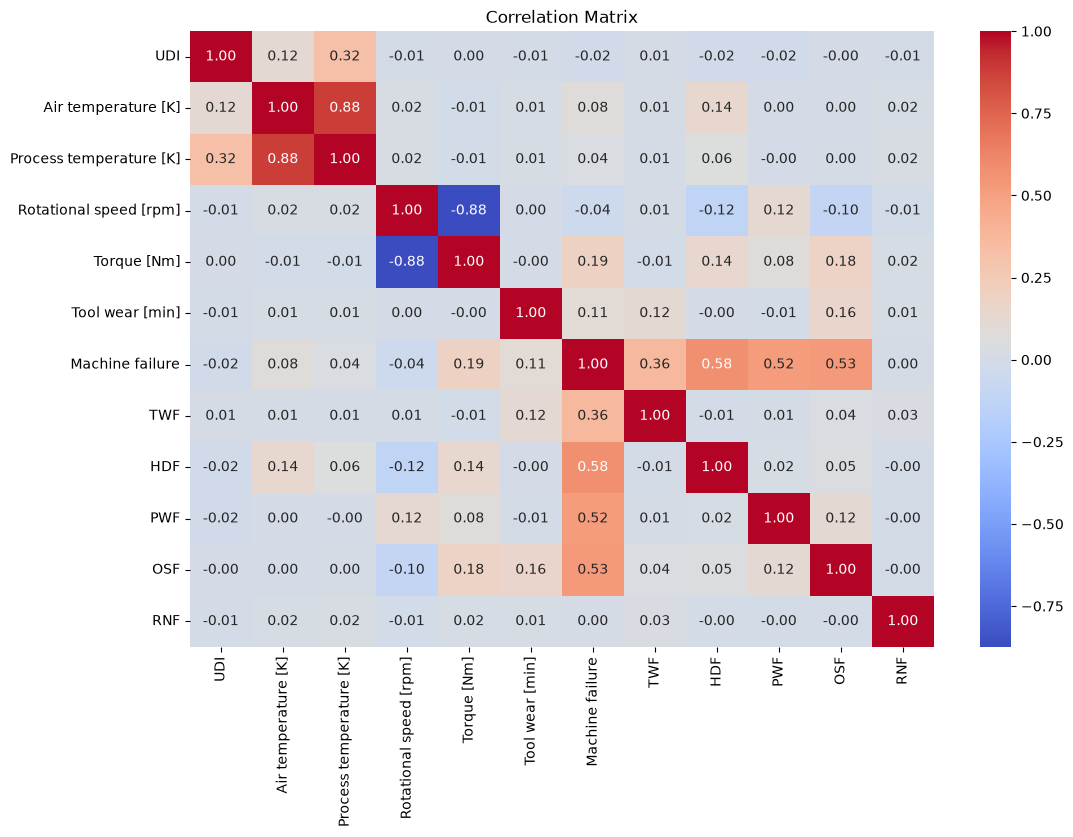

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
corr = (
    df.corr(numeric_only=True)["Machine failure"]
      .sort_values(ascending=False)
)

corr

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

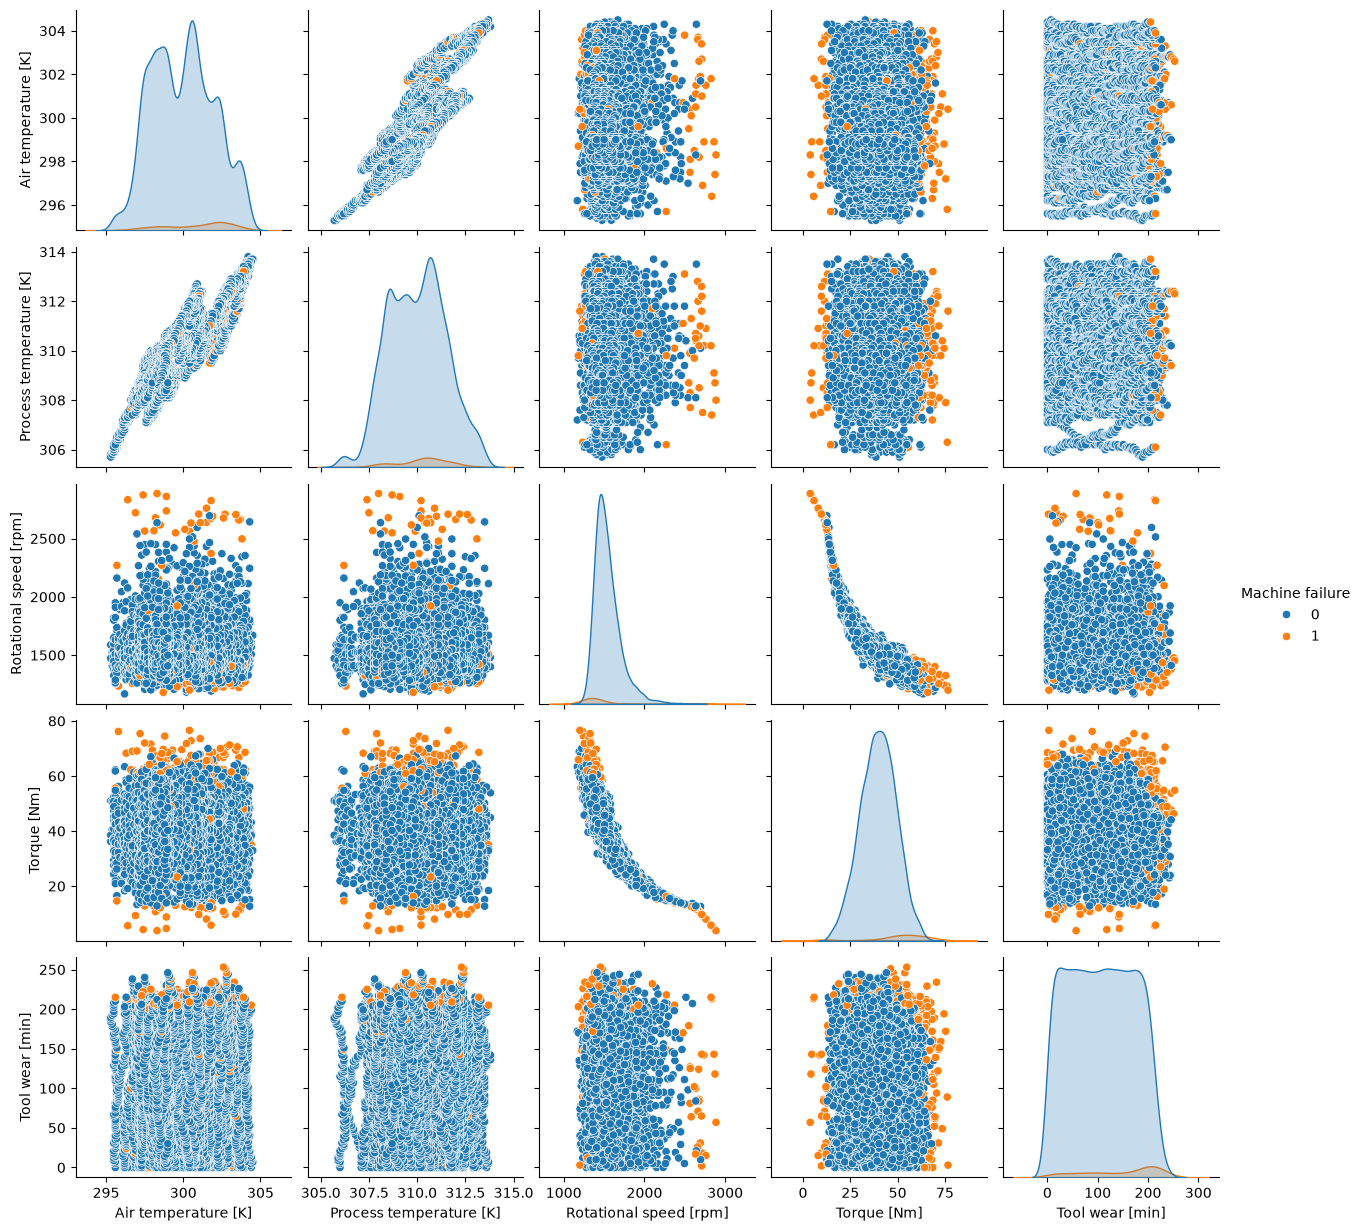

In [21]:
selected = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure"
]

sns.pairplot(
    df[selected],
    hue="Machine failure"
)

plt.show()

In [22]:
failure_cols = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

for col in failure_cols:
    
    print(col)
    
    print(df[col].value_counts())
    
    print("-"*40)

TWF
TWF
0    9954
1      46
Name: count, dtype: int64
----------------------------------------
HDF
HDF
0    9885
1     115
Name: count, dtype: int64
----------------------------------------
PWF
PWF
0    9905
1      95
Name: count, dtype: int64
----------------------------------------
OSF
OSF
0    9902
1      98
Name: count, dtype: int64
----------------------------------------
RNF
RNF
0    9981
1      19
Name: count, dtype: int64
----------------------------------------


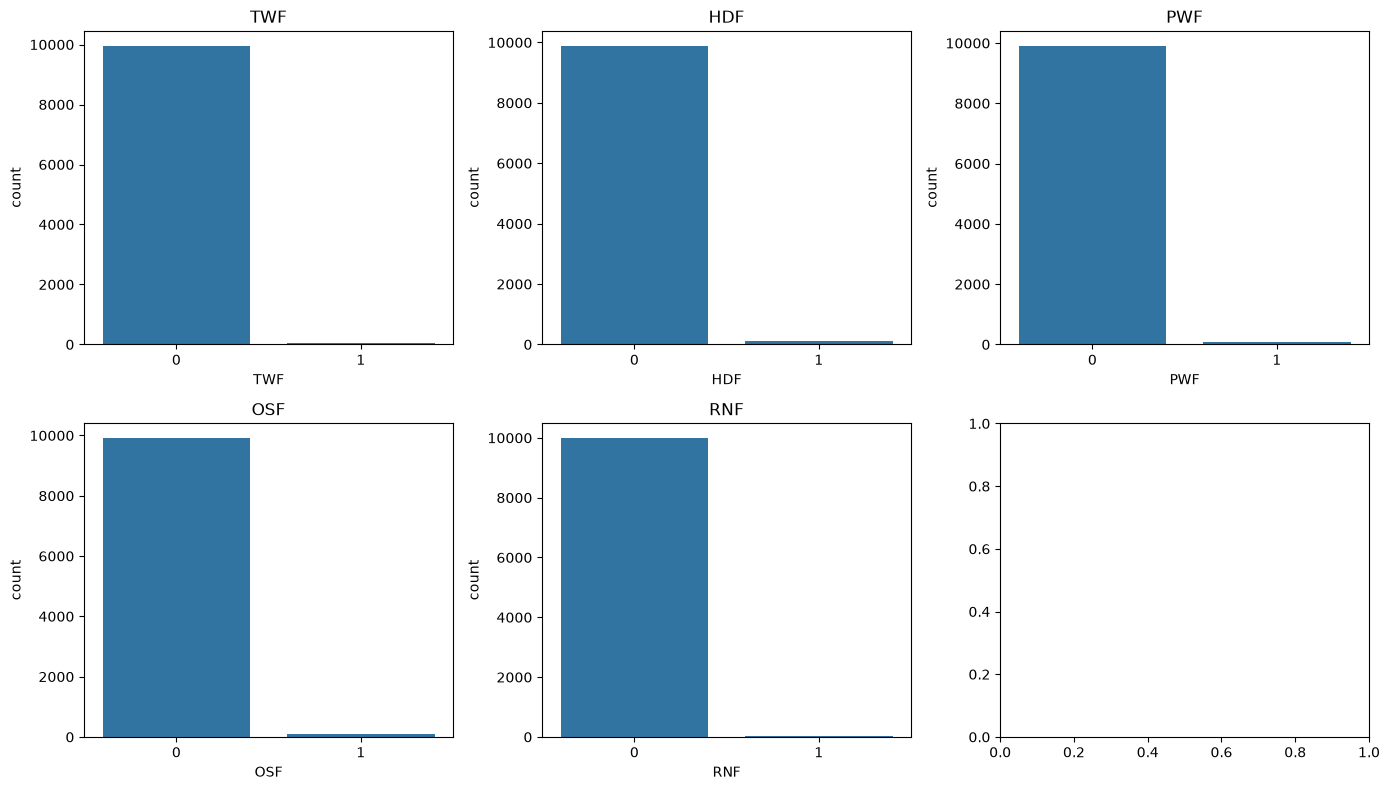

In [23]:
fig, ax = plt.subplots(2,3, figsize=(14,8))

ax = ax.flatten()

for i, col in enumerate(failure_cols):
    
    sns.countplot(
        data=df,
        x=col,
        ax=ax[i]
    )
    
    ax[i].set_title(col)

plt.tight_layout()

plt.show()

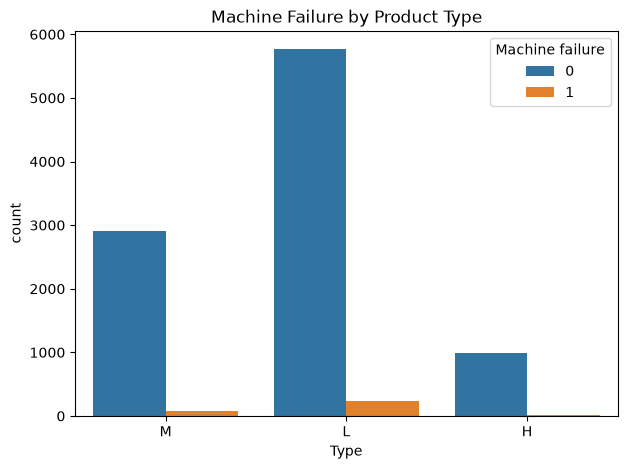

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure"
)

plt.title("Machine Failure by Product Type")

plt.show()

In [25]:
df.groupby("Machine failure")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [26]:
fig = px.scatter(
    df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    color="Machine failure",
    hover_data=["Type"]
)

fig.show()

In [27]:
eda_summary = pd.DataFrame({

    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing": df.isnull().sum().values,
    "Unique": df.nunique().values

})

output_path = PROJECT_ROOT / "reports" / "EDA_Summary.csv"

eda_summary.to_csv(output_path, index=False)

print("EDA Summary Saved Successfully")

EDA Summary Saved Successfully
